In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import h, hbar, c
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from scipy.optimize import minimize, minimize_scalar
from scipy.sparse.linalg import expm_multiply

try:
    from IPython.display import display
except ImportError:
    display = print

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.22})

C_CM_S = c*100.0
DEBYE_C_M = 3.33564e-30
HARTREE_J = 4.3597447222060e-18
MOLECULES = ("H2O2", "H2S2", "H2Se2")

# The three production notebooks use this same output tree.
PROJECT_ROOT = Path(os.environ.get(
    "H2X2_PROJECT_ROOT", Path.cwd()/"H2X2_publication_project"
)).resolve()
NPZ_PATHS = {m: PROJECT_ROOT/"data"/m/"processed"/"dvr_wavefunctions.npz"
             for m in MOLECULES}

# Lightweight fallback permits the doublet/RWA calculation without rerunning
# electronic structure. These are molecular inputs, not control conclusions.
FALLBACK_DOUBLETS = {
    "H2O2": {"Delta_cm1": 10.98417282010652, "mu01_D": 1.29898363285746},
    "H2S2": {"Delta_cm1": 5.635802216514066e-6, "mu01_D": 0.8112525437774057},
    "H2Se2": {"Delta_cm1": 1.7434371919796229e-6, "mu01_D": 0.5122644051257264},
}

print("Project root:", PROJECT_ROOT)
for m, path in NPZ_PATHS.items():
    print(f"{m}: {'FOUND' if path.exists() else 'missing'}  {path}")


Project root: /home/smohtash/H2X2_final/H2X2_publication_project
H2O2: FOUND  /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/processed/dvr_wavefunctions.npz
H2S2: FOUND  /home/smohtash/H2X2_final/H2X2_publication_project/data/H2S2/processed/dvr_wavefunctions.npz
H2Se2: FOUND  /home/smohtash/H2X2_final/H2X2_publication_project/data/H2Se2/processed/dvr_wavefunctions.npz


In [2]:
def load_molecule(molecule):
    path = NPZ_PATHS[molecule]
    if not path.exists():
        x = FALLBACK_DOUBLETS[molecule]
        return {
            "molecule": molecule,
            "Delta_cm1": x["Delta_cm1"],
            "mu01_D": x["mu01_D"],
            "data_mode": "embedded doublet",
            "dvr": None,
        }

    z = np.load(path)
    Ee = np.asarray(z["Ee_ha"], float)
    Eo = np.asarray(z["Eo_ha"], float)
    Pe = np.asarray(z["Pe"], complex)
    Po = np.asarray(z["Po"], complex)
    mu_grid = np.asarray(z["mu_z_D"], float)
    delta_cm1 = abs(Eo[0]-Ee[0]) * HARTREE_J/(h*C_CM_S)
    mu01_D = abs(np.vdot(Pe[:, 0], mu_grid*Po[:, 0]))
    return {
        "molecule": molecule,
        "Delta_cm1": float(delta_cm1),
        "mu01_D": float(mu01_D),
        "data_mode": "recomputed from DVR arrays",
        "dvr": z,
    }

molecular = {m: load_molecule(m) for m in MOLECULES}
doublets = pd.DataFrame([
    {k: v for k, v in molecular[m].items() if k != "dvr"}
    for m in MOLECULES
]).set_index("molecule")
doublets["carrier_Hz"] = doublets.Delta_cm1*C_CM_S
doublets["field_free_L_to_R_s"] = 1/(2*doublets.carrier_Hz)
doublets["electric_coupling"] = np.where(doublets.mu01_D > 0, "YES", "NO")
display(doublets)


,Delta_cm1,mu01_D,data_mode,carrier_Hz,field_free_L_to_R_s,electric_coupling
molecule,,,,,,
H2O2,10.984173,1.298984,recomputed from DVR arrays,3.292972e+11,1.518385e-12,YES
H2S2,0.000006,0.811253,recomputed from DVR arrays,1.689571e+05,2.959331e-06,YES
H2Se2,0.000002,0.512264,recomputed from DVR arrays,5.226693e+04,9.566278e-06,YES


In [3]:
SX = np.array([[0, 1], [1, 0]], complex)
SY = np.array([[0, -1j], [1j, 0]], complex)
SZ = np.array([[1, 0], [0, -1]], complex)
I2 = np.eye(2, dtype=complex)
KET_L = np.array([1, 1], complex)/np.sqrt(2)
KET_R = np.array([1, -1], complex)/np.sqrt(2)

def exact_U(r, phase, tau_final=None, dense=False):
    if tau_final is None:
        tau_final = np.pi/r
    def rhs(tau, y):
        U = y.reshape(2, 2)
        Hdim = 0.5*SZ-r*np.cos(tau+phase)*SX
        return (-1j*Hdim@U).reshape(-1)
    sol = solve_ivp(rhs, (0, float(tau_final)), I2.reshape(-1),
                    method="DOP853", rtol=2e-9, atol=2e-11,
                    dense_output=dense)
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y[:, -1].reshape(2, 2), sol

def rwa_U(r, phase, tau):
    axis = np.cos(phase)*SX+np.sin(phase)*SY
    return expm(-1j*tau*SZ/2) @ expm(+1j*r*tau*axis/2)

def average_gate_infidelity(U, Uref):
    overlap = np.trace(Uref.conj().T@U)
    return float(max(0, 1-np.real((abs(overlap)**2+2)/6)))

def scan_rwa(r_grid, phases):
    rows = []
    for r in r_grid:
        errors = []
        tau = np.pi/r
        for phase in phases:
            U, _ = exact_U(r, phase, tau)
            errors.append(average_gate_infidelity(U, rwa_U(r, phase, tau)))
        rows.append([r, min(errors), np.mean(errors), max(errors)])
    ans = pd.DataFrame(rows, columns=["r", "best", "mean", "worst"])
    ans["worst_envelope"] = np.maximum.accumulate(ans.worst)
    return ans

def log_interpolated_crossing(r, y, threshold):
    hit = np.where(np.asarray(y) >= threshold)[0]
    if not len(hit):
        return np.nan
    i = int(hit[0])
    if i == 0:
        return float(r[0])
    f = (threshold-y[i-1])/(y[i]-y[i-1])
    return float(np.exp(np.log(r[i-1])+f*(np.log(r[i])-np.log(r[i-1]))))

FULL_SCAN = True  # 120 r values x 16 carrier phases; change to False for a quick run.
R_GRID = np.geomspace(1e-2, 1.2, 120 if FULL_SCAN else 40)
PHASES = np.linspace(0, 2*np.pi, 16 if FULL_SCAN else 8, endpoint=False)
rwa_scan = scan_rwa(R_GRID, PHASES)
R_THRESHOLDS = {
    eps: log_interpolated_crossing(rwa_scan.r.to_numpy(),
                                   rwa_scan.worst_envelope.to_numpy(), eps)
    for eps in (0.01, 0.05, 0.10)
}
display(pd.Series(R_THRESHOLDS, name="largest r inside error envelope"))


0.01    0.165409
0.05    0.426094
0.10    0.546971
Name: largest r inside error envelope, dtype: float64

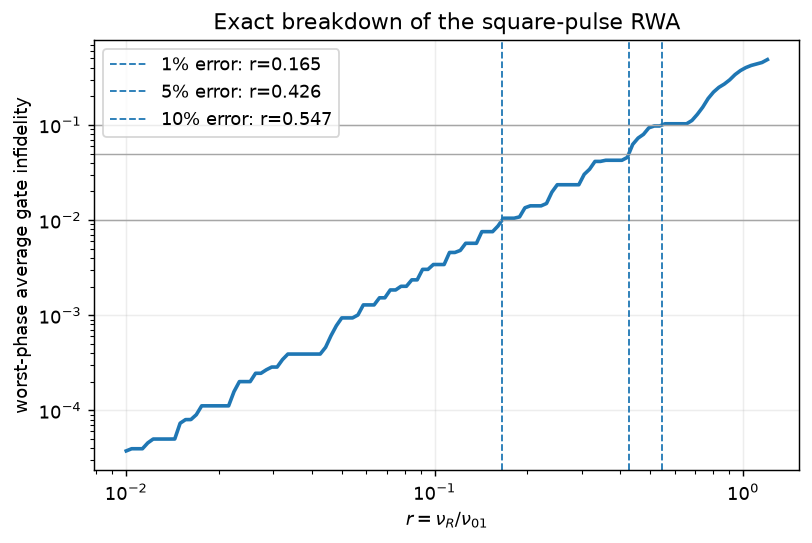

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.loglog(rwa_scan.r, rwa_scan.worst_envelope, lw=2)
for eps, rcrit in R_THRESHOLDS.items():
    ax.axhline(eps, color="0.65", lw=0.8)
    ax.axvline(rcrit, ls="--", lw=1,
               label=f"{100*eps:.0f}% error: r={rcrit:.3f}")
ax.set(xlabel=r"$r=\nu_R/\nu_{01}$",
       ylabel="worst-phase average gate infidelity",
       title="Exact breakdown of the square-pulse RWA")
ax.legend()
plt.show()


## 3. Calculate the fastest 1%-RWA $L\rightarrow R$ pulse

We use the calculated 1% boundary $r_{1\%}$, optimize the experimentally adjustable carrier phase for the prepared $|L\rangle$ state, and then convert the universal solution into molecule-specific carrier frequencies, fields, and pulse durations.

This choice gives the **fastest pulse at the selected RWA tolerance**. A smaller $r$ lowers the field and improves the RWA, at the cost of a longer pulse.


In [5]:
R_TARGET = R_THRESHOLDS[0.01]

def P_R_at_pi(r, phase):
    U, _ = exact_U(r, phase, np.pi/r)
    return float(abs(np.vdot(KET_R, U@KET_L))**2)

phase_grid = np.linspace(0, 2*np.pi, 129, endpoint=False)
p_grid = np.array([P_R_at_pi(R_TARGET, p) for p in phase_grid])
p0 = phase_grid[np.argmax(p_grid)]
step = 2*np.pi/len(phase_grid)
opt = minimize_scalar(lambda p: -P_R_at_pi(R_TARGET, p%(2*np.pi)),
                      bounds=(p0-step, p0+step), method="bounded",
                      options={"xatol": 1e-11})
PHASE_OPT = float(opt.x%(2*np.pi))
P_R_FINAL = float(-opt.fun)

print(f"calculated r_1%       = {R_TARGET:.9f}")
print(f"optimized phase       = {np.degrees(PHASE_OPT):.6f} deg")
print(f"exact P_R at t_pi     = {P_R_FINAL:.9f}")


calculated r_1%       = 0.165409134
optimized phase       = 85.894616 deg
exact P_R at t_pi     = 0.999981595


In [6]:
def pulse_table(r=R_TARGET, Crot=1.0):
    rows = []
    for m, z in doublets.iterrows():
        nu01 = z.carrier_Hz
        nu_R = r*nu01
        field_Vcm = h*nu_R/(Crot*z.mu01_D*DEBYE_C_M)/100
        rows.append({
            "molecule": m,
            "mu01_D": z.mu01_D,
            "carrier_Hz": nu01,
            "Rabi_Hz": nu_R,
            "pi_time_s": 1/(2*nu_R),
            "field_Vcm": field_Vcm,
            "phase_deg": np.degrees(PHASE_OPT),
            "P_R_exact": P_R_FINAL,
        })
    return pd.DataFrame(rows).set_index("molecule")

pulses = pulse_table()
display(pulses)


,mu01_D,carrier_Hz,Rabi_Hz,pi_time_s,field_Vcm,phase_deg,P_R_exact
molecule,,,,,,,
H2O2,1.298984,3.292972e+11,5.446877e+10,9.179573e-12,83295.343744,85.894616,0.999982
H2S2,0.811253,1.689571e+05,2.794705e+04,1.789098e-05,0.068432,85.894616,0.999982
H2Se2,0.512264,5.226693e+04,8.645428e+03,5.783404e-05,0.033525,85.894616,0.999982


In [7]:
def formatted_pulses(df):
    out = pd.DataFrame(index=df.index)
    out["carrier"] = [f"{x/1e9:.3f} GHz" if x >= 1e9 else f"{x/1e3:.3f} kHz"
                      for x in df.carrier_Hz]
    out["Rabi rate"] = [f"{x/1e9:.3f} GHz" if x >= 1e9 else f"{x/1e3:.3f} kHz"
                        for x in df.Rabi_Hz]
    out["pi duration"] = [f"{x*1e12:.3f} ps" if x < 1e-9 else f"{x*1e6:.3f} us"
                          for x in df.pi_time_s]
    out["field"] = [f"{x:.5g} V/cm" for x in df.field_Vcm]
    out["phase"] = [f"{x:.3f} deg" for x in df.phase_deg]
    out["exact P_R"] = [f"{x:.8f}" for x in df.P_R_exact]
    return out

display(formatted_pulses(pulses))


,carrier,Rabi rate,pi duration,field,phase,exact P_R
molecule,,,,,,
H2O2,329.297 GHz,54.469 GHz,9.180 ps,83295 V/cm,85.895 deg,0.99998159
H2S2,168.957 kHz,27.947 kHz,17.891 us,0.068432 V/cm,85.895 deg,0.99998159
H2Se2,52.267 kHz,8.645 kHz,57.834 us,0.033525 V/cm,85.895 deg,0.99998159


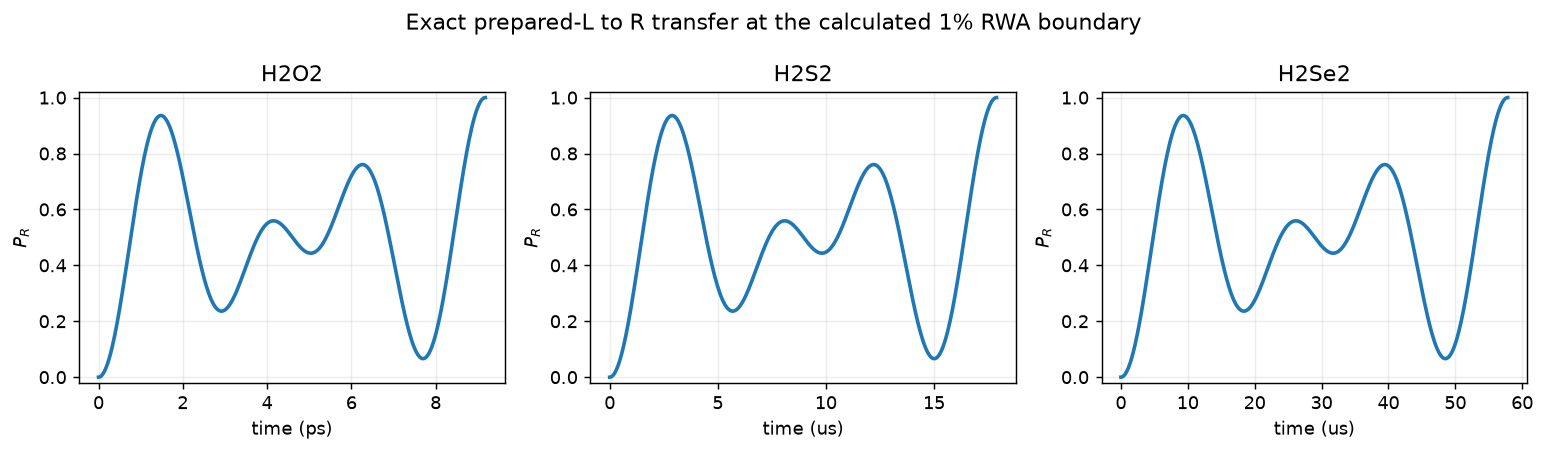

In [8]:
# Exact L->R traces on the physical time axis for all three molecules.
tau_pi = np.pi/R_TARGET
_, solution = exact_U(R_TARGET, PHASE_OPT, tau_pi, dense=True)
tau = np.linspace(0, tau_pi, 500)
U_t = solution.sol(tau).T.reshape(-1, 2, 2)
P_R_tau = np.array([abs(np.vdot(KET_R, U@KET_L))**2 for U in U_t])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5))
for ax, m in zip(axes, MOLECULES):
    t = tau/(2*np.pi*doublets.loc[m, "carrier_Hz"])
    scale, unit = (1e12, "ps") if t[-1] < 1e-9 else (1e6, "us")
    ax.plot(t*scale, P_R_tau, lw=2)
    ax.set(title=m, xlabel=f"time ({unit})", ylabel=r"$P_R$")
    ax.set_ylim(-0.02, 1.02)
fig.suptitle("Exact prepared-L to R transfer at the calculated 1% RWA boundary")
fig.tight_layout()
plt.show()


,proposed_field_Vcm,max_eta_at_proposed_field,sum_eta2_at_proposed_field,dominant_unwanted_pair,field_at_max_eta_0.1_Vcm,two_level_at_proposed_pulse
molecule,,,,,,
H2O2,83295.343744,1.201454e-03,1.533549e-06,"(1, 2)",6.932878e+06,PASS
H2S2,0.068432,1.983669e-11,8.597860e-22,"(1, 4)",3.449749e+08,PASS
H2Se2,0.033525,6.759368e-12,1.334462e-22,"(1, 4)",4.959787e+08,PASS


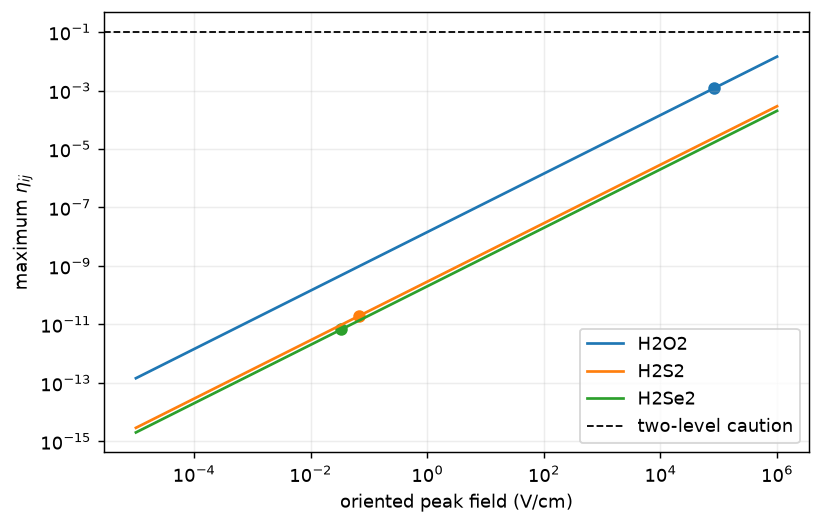

In [20]:
def full_dvr_basis(z):
    Ee = np.asarray(z["Ee_ha"], float)
    Eo = np.asarray(z["Eo_ha"], float)
    Pe = np.asarray(z["Pe"], complex)
    Po = np.asarray(z["Po"], complex)
    mu_grid = np.asarray(z["mu_z_D"], float)

    states = [Pe[:, i] for i in range(Pe.shape[1])] + [Po[:, i] for i in range(Po.shape[1])]
    energy = np.r_[Ee, Eo]
    parity = np.array(["even"]*len(Ee)+["odd"]*len(Eo))
    order = np.argsort(energy)
    energy = energy[order]
    parity = parity[order]
    U = np.column_stack([states[i] for i in order])
    MU = U.conj().T@np.diag(mu_grid)@U
    ie = np.where(parity == "even")[0][0]
    io = np.where(parity == "odd")[0][0]
    return energy, parity, MU, ie, io

def leakage_metrics(z, field_Vcm):
    E, parity, MU, ie, io = full_dvr_basis(z)
    omega01 = abs(E[io]-E[ie])*HARTREE_J/hbar
    ratios = []
    labels = []
    for i in (ie, io):
        for j in range(len(E)):
            if j in (ie, io) or parity[j] == parity[i]:
                continue
            omegaij = abs(E[j]-E[i])*HARTREE_J/hbar
            detuning = abs(omegaij-omega01)
            if detuning == 0:
                ratio = np.inf
            else:
                coupling = abs(MU[i, j])*DEBYE_C_M*(field_Vcm*100)/(2*hbar)
                ratio = float(coupling/detuning)
            ratios.append(ratio)
            labels.append((i, j))
    ratios = np.asarray(ratios)
    k = int(np.argmax(ratios))
    return {
        "max_eta": float(ratios[k]),
        "sum_eta_squared": float(np.sum(ratios**2)),
        "dominant_pair": labels[k],
    }

have_all_dvr = all(molecular[m]["dvr"] is not None for m in MOLECULES)
if not have_all_dvr:
    missing = [str(NPZ_PATHS[m]) for m in MOLECULES if molecular[m]["dvr"] is None]
    print("Multilevel audit not run. Execute the three production notebooks first.")
    print("Missing files:")
    print("\n".join(missing))
else:
    rows = []
    field_grid = np.logspace(-5, 6, 300)
    curves = {}
    for m in MOLECULES:
        z = molecular[m]["dvr"]
        eta = np.array([leakage_metrics(z, E0)["max_eta"] for E0 in field_grid])
        curves[m] = eta
        proposed = leakage_metrics(z, pulses.loc[m, "field_Vcm"])
        # eta is exactly linear in field in this perturbative diagnostic,
        # so calculate the caution crossing directly instead of returning NaN
        # when it lies outside the plotting grid.
        failure_field = (pulses.loc[m, "field_Vcm"]*0.1/
                         proposed["max_eta"])
        rows.append({
            "molecule": m,
            "proposed_field_Vcm": pulses.loc[m, "field_Vcm"],
            "max_eta_at_proposed_field": proposed["max_eta"],
            "sum_eta2_at_proposed_field": proposed["sum_eta_squared"],
            "dominant_unwanted_pair": proposed["dominant_pair"],
            "field_at_max_eta_0.1_Vcm": failure_field,
            "two_level_at_proposed_pulse": "CAUTION" if proposed["max_eta"] >= 0.1 else "PASS",
        })
    leakage_table = pd.DataFrame(rows).set_index("molecule")
    display(leakage_table)

    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    for m in MOLECULES:
        ax.loglog(field_grid, curves[m], label=m)
        ax.scatter(pulses.loc[m, "field_Vcm"],
                   leakage_table.loc[m, "max_eta_at_proposed_field"], s=35)
    ax.axhline(0.1, color="k", ls="--", lw=1, label="two-level caution")
    ax.set(xlabel="oriented peak field (V/cm)", ylabel=r"maximum $\eta_{ij}$",)
#            title="Full-DVR leakage test"
    ax.legend()
    plt.show()


In [10]:
# ---- Calibrate a smooth sin^2 pulse in the exact two-state model ----
TAU_FINAL = np.pi/R_TARGET

def exact_U_envelope(r_peak, phase, envelope="square", dense=False):
    def shape(tau):
        if envelope == "square":
            return 1.0
        if envelope == "sin2":
            return np.sin(np.pi*tau/TAU_FINAL)**2
        raise ValueError(envelope)
    def rhs(tau, y):
        U = y.reshape(2, 2)
        Hdim = 0.5*SZ-r_peak*shape(tau)*np.cos(tau+phase)*SX
        return (-1j*Hdim@U).reshape(-1)
    sol = solve_ivp(rhs, (0, TAU_FINAL), I2.reshape(-1), method="DOP853",
                    rtol=2e-9, atol=2e-11, dense_output=dense)
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y[:, -1].reshape(2, 2), sol

def shaped_target_probability(x):
    peak_scale, phase = float(x[0]), float(x[1]%(2*np.pi))
    U, _ = exact_U_envelope(peak_scale*R_TARGET, phase, "sin2")
    return float(abs(np.vdot(KET_R, U@KET_L))**2)

# A sin^2 envelope has half the area of a square envelope at equal peak;
# peak_scale=2 is therefore the equal-area starting point.
smooth_opt = minimize(lambda x: -shaped_target_probability(x),
                      x0=np.array([2.0, PHASE_OPT]),
                      bounds=[(1.5, 2.5), (0, 2*np.pi)],
                      method="Nelder-Mead",
                      options={"xatol": 1e-8, "fatol": 1e-10,
                               "maxiter": 300})
SIN2_PEAK_SCALE = float(smooth_opt.x[0])
SIN2_PHASE = float(smooth_opt.x[1]%(2*np.pi))
SIN2_P_R_2LEVEL = shaped_target_probability(smooth_opt.x)

print(f"square: peak ratio={R_TARGET:.9f}, phase={np.degrees(PHASE_OPT):.6f} deg")
print(f"sin^2 : peak ratio={SIN2_PEAK_SCALE*R_TARGET:.9f}, "
      f"peak/square={SIN2_PEAK_SCALE:.6f}, "
      f"phase={np.degrees(SIN2_PHASE):.6f} deg")
print(f"sin^2 exact two-level endpoint P_R={SIN2_P_R_2LEVEL:.9f}")


square: peak ratio=0.165409134, phase=85.894616 deg
sin^2 : peak ratio=0.330529413, peak/square=1.998254, phase=85.894617 deg
sin^2 exact two-level endpoint P_R=1.000000000


In [11]:
def sinc_rad(x):
    # sin(x)/x, evaluated stably.
    return np.sinc(np.asarray(x)/np.pi)

def propagate_dvr_pulse(z, carrier_Hz, duration_s, field_peak_Vcm,
                        phase, envelope="square", n_states=32,
                        n_steps=1200, store_trace=False):
    # Interaction-picture, carrier-integrated midpoint Magnus propagation.
    energy_ha, parity, mu_D, ie_full, io_full = full_dvr_basis(z)
    n_states = min(int(n_states), len(energy_ha))
    if max(ie_full, io_full) >= n_states:
        raise ValueError("n_states truncation removed a target-doublet state")

    energy_J = energy_ha[:n_states]*HARTREE_J
    mu_Cm = mu_D[:n_states, :n_states]*DEBYE_C_M
    ie, io = ie_full, io_full
    reference = 0.5*(energy_J[ie]+energy_J[io])
    energy_J = energy_J-reference
    omega_ij = (energy_J[:, None]-energy_J[None, :])/hbar
    omega_c = 2*np.pi*carrier_Hz
    field_peak_Vm = field_peak_Vcm*100

    a = np.zeros(n_states, complex)
    a[ie] = 1/np.sqrt(2)
    a[io] = 1/np.sqrt(2)
    ket_R = np.zeros(n_states, complex)
    ket_R[ie] = 1/np.sqrt(2)
    ket_R[io] = -1/np.sqrt(2)

    dt = duration_s/n_steps
    trace = []
    for k in range(n_steps):
        t0, t1 = k*dt, (k+1)*dt
        tm = 0.5*(t0+t1)
        if envelope == "square":
            fmid = 1.0
        elif envelope == "sin2":
            fmid = np.sin(np.pi*tm/duration_s)**2
        else:
            raise ValueError(envelope)

        plus = omega_ij+omega_c
        minus = omega_ij-omega_c
        field_average = 0.5*field_peak_Vm*fmid*(
            np.exp(1j*phase)*np.exp(1j*plus*tm)*sinc_rad(plus*dt/2)
            + np.exp(-1j*phase)*np.exp(1j*minus*tm)*sinc_rad(minus*dt/2)
        )
        Vbar = -mu_Cm*field_average
        Vbar = 0.5*(Vbar+Vbar.conj().T)  # remove roundoff asymmetry
        a = expm_multiply((-1j*dt/hbar)*Vbar, a)

        if store_trace:
            c_state = np.exp(-1j*energy_J*t1/hbar)*a
            p_doublet = float(abs(c_state[ie])**2+abs(c_state[io])**2)
            p_R = float(abs(np.vdot(ket_R, c_state))**2)
            trace.append((t1/duration_s, p_R,
                          max(0.0, 1.0-p_doublet)))

    c_state = np.exp(-1j*energy_J*duration_s/hbar)*a
    p_doublet = float(abs(c_state[ie])**2+abs(c_state[io])**2)
    p_R = float(abs(np.vdot(ket_R, c_state))**2)
    result = {
        "P_R": p_R,
        "P_doublet": p_doublet,
        "P_leak": max(0.0, 1.0-p_doublet),
        "norm_error": abs(float(np.vdot(c_state, c_state).real)-1.0),
        "n_states": n_states,
        "n_steps": n_steps,
    }
    if store_trace:
        result["trace"] = np.asarray(trace)
    return result


In [12]:
# ---- Full multilevel calculation for the actual molecule-specific pulses ----
N_STATES = 32
N_STEPS = 1200
RUN_MULTILEVEL_CONVERGENCE = True

if not have_all_dvr:
    print("Direct multilevel propagation not run: the three production DVR files are required.")
else:
    multilevel_rows = []
    multilevel_traces = {}
    for m in MOLECULES:
        z = molecular[m]["dvr"]
        nu01 = pulses.loc[m, "carrier_Hz"]
        duration = pulses.loc[m, "pi_time_s"]
        square_field = pulses.loc[m, "field_Vcm"]

        square = propagate_dvr_pulse(
            z, nu01, duration, square_field, PHASE_OPT,
            envelope="square", n_states=N_STATES,
            n_steps=N_STEPS, store_trace=True)
        smooth = propagate_dvr_pulse(
            z, nu01, duration, SIN2_PEAK_SCALE*square_field, SIN2_PHASE,
            envelope="sin2", n_states=N_STATES,
            n_steps=N_STEPS, store_trace=True)

        # Exact field-free result at the same endpoint.
        p_R_field_free = float(np.sin(np.pi*nu01*duration)**2)
        multilevel_traces[(m, "square")] = square.pop("trace")
        multilevel_traces[(m, "sin2")] = smooth.pop("trace")

        for pulse_name, field, result in (
            ("field-free", 0.0,
             {"P_R": p_R_field_free, "P_doublet": 1.0,
              "P_leak": 0.0, "norm_error": 0.0,
              "n_states": N_STATES, "n_steps": N_STEPS}),
            ("square", square_field, square),
            ("sin2", SIN2_PEAK_SCALE*square_field, smooth),
        ):
            multilevel_rows.append({"molecule": m, "pulse": pulse_name,
                                    "peak_field_Vcm": field, **result})

    multilevel = pd.DataFrame(multilevel_rows).set_index(["molecule", "pulse"])
    display(multilevel)


peak_field_Vcm       P_R  P_doublet        P_leak  \
molecule pulse                                                           
H2O2     field-free        0.000000  0.005125        1.0  0.000000e+00   
         square        83295.343744  0.999981        1.0  7.721395e-08   
         sin2         166445.228659  1.000000        1.0  8.215650e-15   
H2S2     field-free        0.000000  0.005125        1.0  0.000000e+00   
         square            0.068432  0.999982        1.0  0.000000e+00   
         sin2              0.136744  1.000000        1.0  0.000000e+00   
H2Se2    field-free        0.000000  0.005125        1.0  0.000000e+00   
         square            0.033525  0.999982        1.0  0.000000e+00   
         sin2              0.066992  1.000000        1.0  4.329870e-15   

                       norm_error  n_states  n_steps  
molecule pulse                                        
H2O2     field-free  0.000000e+00        32     1200  
         square      8.881784e-16        20     1200  
         sin2        1.776357e-15        20     1200  
H2S2     field-free  0.000000e+00        32     1200  
         square      8.881784e-16        20     1200  
         sin2        6.883383e-15        20     1200  
H2Se2    field-free  0.000000e+00        32     1200  
         square      1.554312e-15        20     1200  
         sin2        4.440892e-15        20     1200

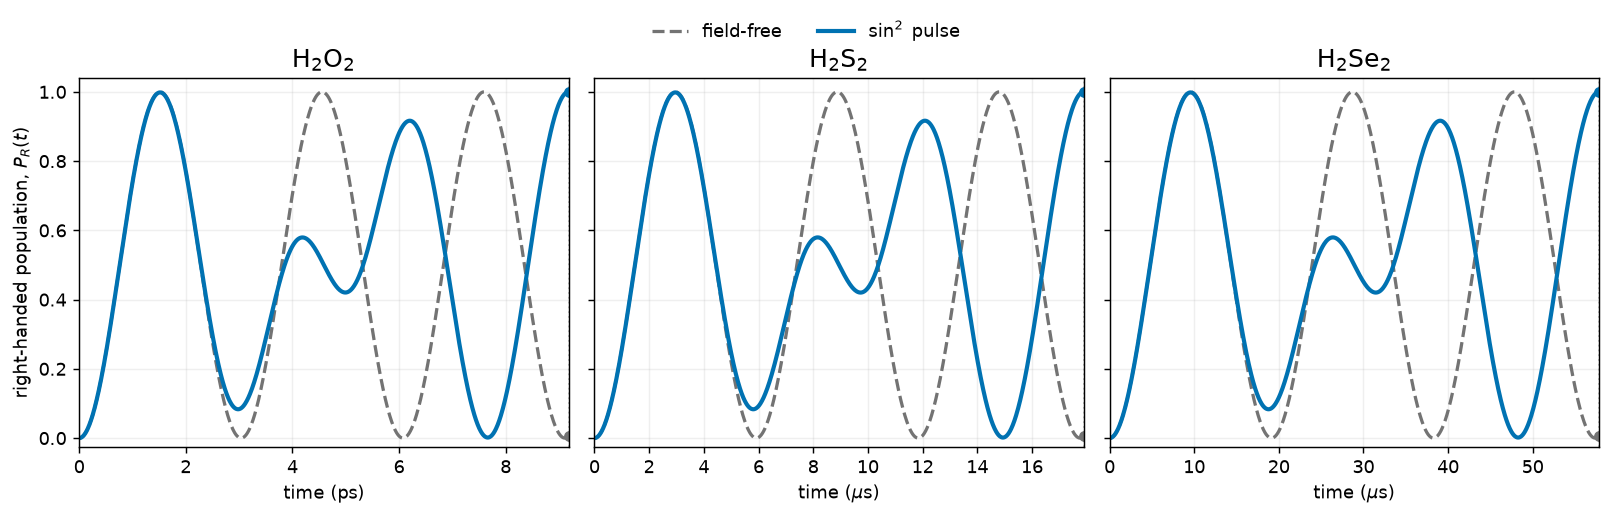

In [24]:
# ---- Main-text Figure 3: full-DVR handedness control ----
# Shows only the physically smooth sin^2 pulse and the field-free reference.
# The square-pulse results remain available for the Supporting Information.

if have_all_dvr:

    molecule_labels = {
        "H2O2": r"$\mathrm{H_2O_2}$",
        "H2S2": r"$\mathrm{H_2S_2}$",
        "H2Se2": r"$\mathrm{H_2Se_2}$",
    }

    drive_color = "#0072B2"

    fig, axes = plt.subplots(
        1, 3,
        figsize=(12.5, 3.8),
        sharey=True
    )

    for ax, m in zip(axes, MOLECULES):

        # Full-DVR trace for the smooth pulse.
        # Columns are: normalized time, P_R(t), leakage(t).
        sm = multilevel_traces[(m, "sin2")]

        duration_s = pulses.loc[m, "pi_time_s"]
        carrier_Hz = pulses.loc[m, "carrier_Hz"]

        # Convert normalized propagation time to physical time.
        t_s = sm[:, 0] * duration_s
        P_R_drive = sm[:, 1]

        # Add the exact initial point explicitly.
        t_s = np.insert(t_s, 0, 0.0)
        P_R_drive = np.insert(P_R_drive, 0, 0.0)

        # Exact field-free evolution of the prepared localized L state.
        P_R_free = np.sin(np.pi * carrier_Hz * t_s)**2

        # Choose appropriate physical time units.
        if duration_s < 1.0e-9:
            time_scale = 1.0e12
            time_unit = "ps"
        else:
            time_scale = 1.0e6
            time_unit = r"$\mu$s"

        t_plot = t_s * time_scale
        t_pi_plot = duration_s * time_scale

        # Endpoint results from the full multilevel propagation.
        P_free_end = multilevel.loc[(m, "field-free"), "P_R"]
        P_drive_end = multilevel.loc[(m, "sin2"), "P_R"]
        P_leak_end = multilevel.loc[(m, "sin2"), "P_leak"]

        # Dynamics.
        ax.plot(
            t_plot,
            P_R_free,
            color="0.45",
            linestyle="--",
            linewidth=1.8,
            label="field-free"
        )

        ax.plot(
            t_plot,
            P_R_drive,
            color=drive_color,
            linewidth=2.3,
            label=r"$\sin^2$ pulse"
        )

        # Mark the common pulse endpoint.
        ax.axvline(
            t_pi_plot,
            color="0.75",
            linestyle=":",
            linewidth=1.0
        )

        ax.plot(
            t_pi_plot,
            P_free_end,
            marker="o",
            markersize=5,
            color="0.45"
        )

        ax.plot(
            t_pi_plot,
            P_drive_end,
            marker="o",
            markersize=5,
            color=drive_color
        )

#         # Endpoint annotation.
#         if P_leak_end < 1.0e-14:
#             leakage_text = r"$P_{\mathrm{leak}}<10^{-14}$"
#         else:
#             leakage_text = (
#                 rf"$P_{{\mathrm{{leak}}}}={P_leak_end:.1e}$"
#             )

#         annotation = (
#             rf"$P_R^{{(0)}}(t_\pi)={P_free_end:.4f}$"
#             "\n"
#             rf"$P_R^{{(\mathrm{{drive}})}}(t_\pi)={P_drive_end:.6f}$"
#             "\n"
#             + leakage_text
#         )

#         ax.text(
#             0.04,
#             0.96,
#             annotation,
#             transform=ax.transAxes,
#             ha="left",
#             va="top",
#             fontsize=9,
#             bbox=dict(
#                 boxstyle="round,pad=0.30",
#                 facecolor="white",
#                 edgecolor="0.80",
#                 alpha=0.90
#             )
#         )

        ax.set_title(molecule_labels.get(m, m), fontsize=14)
        ax.set_xlabel(f"time ({time_unit})")
        ax.set_xlim(0.0, t_pi_plot)
        ax.set_ylim(-0.025, 1.04)
        ax.grid(alpha=0.20)

    axes[0].set_ylabel(r"right-handed population, $P_R(t)$")

    # A single legend for the entire figure.
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=2,
        frameon=False
    )

#     fig.suptitle(
#         "Full-DVR electric-field control of molecular handedness",
#         y=1.12,
#         fontsize=14
#     )

    fig.tight_layout()

    # Publication-quality output.
    fig.savefig(
        "H2X2_full_DVR_handedness_control.pdf",
        bbox_inches="tight"
    )
    fig.savefig(
        "H2X2_full_DVR_handedness_control.png",
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()

In [15]:
# ---- Numerical convergence: basis size and time step ----
if have_all_dvr and RUN_MULTILEVEL_CONVERGENCE:
    convergence_rows = []
    convergence_cases = [(16, 600), (32, 600), (16, 1200), (32, 1200)]
    for m in MOLECULES:
        z = molecular[m]["dvr"]
        nu01 = pulses.loc[m, "carrier_Hz"]
        duration = pulses.loc[m, "pi_time_s"]
        field = pulses.loc[m, "field_Vcm"]
        for n_states, n_steps in convergence_cases:
            result = propagate_dvr_pulse(
                z, nu01, duration, field, PHASE_OPT, envelope="square",
                n_states=n_states, n_steps=n_steps, store_trace=False)
            convergence_rows.append({"molecule": m, **result})
    convergence = pd.DataFrame(convergence_rows).set_index(
        ["molecule", "n_states", "n_steps"])
    display(convergence)


P_R  P_doublet        P_leak    norm_error
molecule n_states n_steps                                                 
H2O2     16       600      0.999981        1.0  7.721555e-08  1.731948e-14
         20       600      0.999981        1.0  7.721555e-08  1.310063e-14
         16       1200     0.999981        1.0  7.721394e-08  3.996803e-15
         20       1200     0.999981        1.0  7.721395e-08  8.881784e-16
H2S2     16       600      0.999982        1.0  0.000000e+00  8.437695e-15
         20       600      0.999982        1.0  0.000000e+00  8.437695e-15
         16       1200     0.999982        1.0  0.000000e+00  8.881784e-16
         20       1200     0.999982        1.0  0.000000e+00  8.881784e-16
H2Se2    16       600      0.999982        1.0  0.000000e+00  8.659740e-15
         20       600      0.999982        1.0  0.000000e+00  8.659740e-15
         16       1200     0.999982        1.0  0.000000e+00  1.776357e-15
         20       1200     0.999982        1.0  0.000000e+00  1.554312e-15